## 0. Setup

In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [4]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "v12_replacements"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def generate_colormap(N):
    arr = np.arange(N) / N
    N_up = int(math.ceil(N / 7) * 7)
    arr.resize(N_up)
    arr = arr.reshape(7, N_up // 7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:, 3].size
    a = n // 2
    b = n - a

    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a, i] *= np.linspace(0.2, 1, a)
    ret[a:, 3] *= np.linspace(1, 0.3, b)

    return ret[:N]  # Return only the requested number of colors

## 1. Load MapSolve boundaries

In [7]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [8]:
gdf.duplicated().sum()

22270

In [9]:
gdf = gdf.drop_duplicates()

<Axes: >

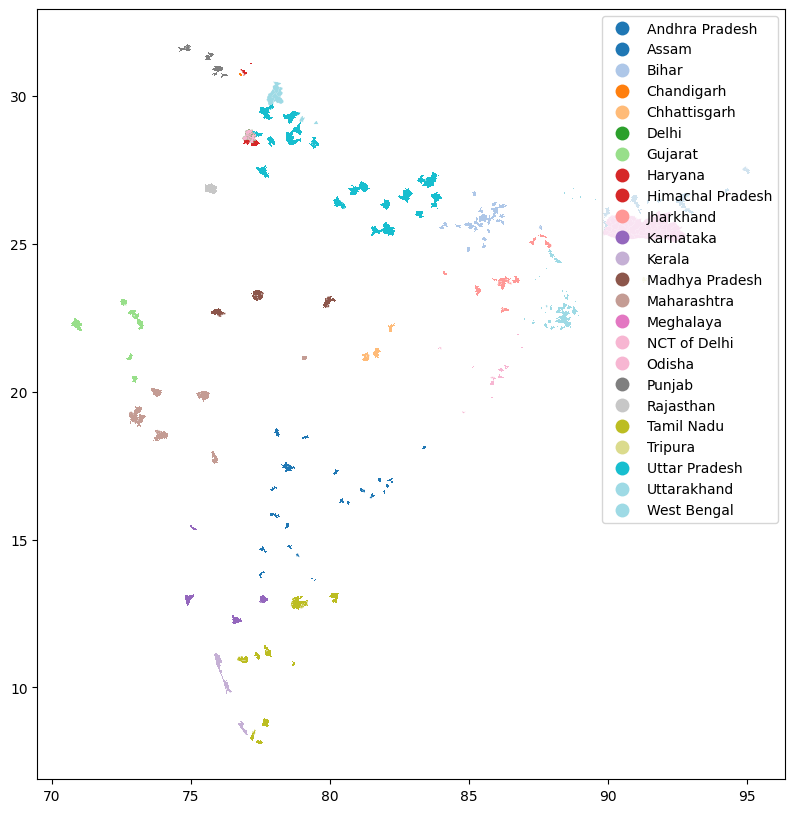

In [10]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

## 2. Load sampled wards data

In [11]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "v9_corrected_counts"
    / "Merged Wards with Quality Checks.csv"
)

### 2.1 Rename and clean both datasets

In [12]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [13]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [14]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

In [15]:
sample_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
0,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,1.0,Shimla (M Corp.) WARD NO.-0001,800137-1,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,1,0,0,1
1,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,16.0,Shimla (M Corp.) WARD NO.-0016,800137-16,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
2,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,19.0,Shimla (M Corp.) WARD NO.-0019,800137-19,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,1,0,0,1
3,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,22.0,Shimla (M Corp.) WARD NO.-0022,800137-22,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
4,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,23.0,Shimla (M Corp.) WARD NO.-0023,800137-23,...,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574173.0,1.0,Peerzadguda (CT) WARD NO.-0001,574173-1,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
1015,90.0,Telangana,538.0,Mahbubnagar,4568.0,Mahbubnagar,802922.0,4.0,Mahbubnagar (M) WARD NO.-0004,802922-4,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,1,1,0,1
1016,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579683.0,0.0,V. Venkatayapalem,579683-0,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,1,0,0,1
1017,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579685.0,1.0,Khanapuram Haveli (CT) WARD NO.-0001,579685-1,...,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1


## 3. Filter MapSolve boundaries to sampled areas

### 3.1 Filter to IFS and subset sample data to phase 2 states

In [16]:
replacement_tv_codes = [227041, 482460, 361598]
selected_states = ["Bihar", "Madhya Pradesh", "Jharkhand"]

In [17]:
filtered_df = sample_df[sample_df["TV Code"].isin(replacement_tv_codes)].copy()

In [18]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
348,10.0,Bihar,215.0,Darbhanga,1184.0,Darbhanga,227041.0,0.0,Belhar,227041-0,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
551,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,361598.0,1.0,Bhim Kanari (CT) WARD NO.-0001,361598-1,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
658,23.0,Madhya Pradesh,444.0,Bhopal,3581.0,Huzur,482460.0,0.0,Kurana,482460-0,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1


### 3.2 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [19]:
filtered_df = filtered_df[filtered_df["PSU Type"] != "none"]

In [20]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)
348,10.0,Bihar,215.0,Darbhanga,1184.0,Darbhanga,227041.0,0.0,Belhar,227041-0,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
551,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,361598.0,1.0,Bhim Kanari (CT) WARD NO.-0001,361598-1,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1
658,23.0,Madhya Pradesh,444.0,Bhopal,3581.0,Huzur,482460.0,0.0,Kurana,482460-0,...,No,False,True,False,GOOD - Town/Village boundary given as expected,town_village,0,1,0,1


In [21]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)


#### Drop duplicate rows if PSU is TV or Subdistrict

In [22]:
filtered_df = filtered_df[
    # if the PSU Type is "town_village", then drop any duplicated rows with the same TV Code
    ~(
        (filtered_df["PSU Type"] == "town_village")
        & (filtered_df.duplicated(subset=["TV Code"], keep="first"))
    )
    # similar for subdistrict
    & ~(
        (filtered_df["PSU Type"] == "subdistrict")
        & (filtered_df.duplicated(subset=["Subdistrict Code"], keep="first"))
    )
]

filtered_df.value_counts("PSU Type")

PSU Type
town_village    3
Name: count, dtype: int64

#### Duplicated wards

In [23]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2,Ward Count (All)


In [24]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 3
Number of rows after dropping PCA_ID duplicates: 3


In [25]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

## 4. Merge shapes at the respective PSU level

### Town/Village

In [26]:
# TV codes to match
tv_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "town_village", "TV Code"
].unique()
len(tv_codes_to_match)

3

In [27]:
tv_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
        gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
        on=["TV Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
tv_gdf.shape

(3, 43)

### Combine

In [28]:
combined_gdf = tv_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

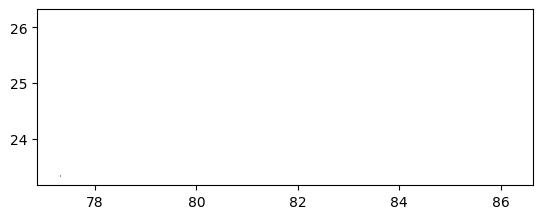

In [29]:
combined_gdf.plot(column="State Name")

In [30]:
combined_gdf[["PSU Type", "Ward Count (All)", "Ward Count IFS", "Ward Count Panel", "Ward Count Panel Round 2"]]

,PSU Type,Ward Count (All),Ward Count IFS,Ward Count Panel,Ward Count Panel Round 2
0,town_village,1,0,1,0
1,town_village,1,0,1,0
2,town_village,1,0,1,0


#### Add unique overall ID column

In [31]:
# add an ID column that is unique across all rows. It should be WARD_{PCA_ID} if the PSU Type is "ward", TV_{TV Code} if the PSU Type is "town_village", and SUBDISTRICT_{Subdistrict Code} if the PSU Type is "subdistrict"
combined_gdf["PSU_ID"] = combined_gdf.apply(
    lambda row: f"WARD_{row['PCA_ID']}"
    if row["PSU Type"] == "ward"
    else f"TV_{row['TV Code']}"
    if row["PSU Type"] == "town_village"
    else f"SUBDISTRICT_{row['Subdistrict Code']}",
    axis=1,
).astype(str)

In [32]:
combined_gdf[combined_gdf.duplicated(subset=["PSU_ID"], keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PSU_ID


In [33]:
combined_gdf = combined_gdf.drop_duplicates(subset=["PSU_ID"], keep="first")

In [34]:
len(combined_gdf) == combined_gdf["PSU_ID"].nunique()

True

In [35]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

In [36]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "all_sampled_PSUs",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Belhar' of field all_sampled_PSUs.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '227041-0' of field all_sampled_PSUs.Ward Code parsed incompletely to real 227041.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Town/Village boundary given as expected' for boolean field all_sampled_PSUs.TV Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'town_village' for boolean field all_sampled_PSUs.SubDistrict Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw

## 5. Download rooftops

### Functions

#### S2 cell shapes

In [37]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.

    Parameters:
    - s2_cell_id (int): The S2 cell ID

    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)

    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)

    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))

    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])

    # Create a shapely polygon
    return Polygon(vertices)


def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.

    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)

    return gpd.GeoDataFrame(
        {"s2_cell_id": s2_cell_ids, "geometry": geometries}, crs="EPSG:4326"
    )

#### Find IDs of overlapping S2 cells

In [38]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    # check if crs is set to WGS84 (EPSG:4326)
    if points.crs is None or points.crs.to_string() != "EPSG:4326":
        raise ValueError("Points GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # convert points to S2 cell IDs
    s2_cell_id_list = points.geometry.apply(
        lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level)
    )
    s2_cell_ids = s2_cell_id_list.unique().tolist()

    return s2_cell_ids


def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.

    Iteratively checks if any area is not covered by an S2 cell and continues until all areas are covered.

    Parameters:
    - gdf: GeoDataFrame in WGS84 (EPSG:4326) CRS
    - level: int

    Returns:
    - list[int]: List of S2 cell IDs
    """

    # check if crs is set to WGS84 (EPSG:4326)
    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        raise ValueError("GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # generate initial S2 cell IDs from the GeoDataFrame centroids
    points = gdf.geometry.centroid.to_frame(name="geometry")
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    # get initial S2 cell shapes and check for full coverage
    s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids)
    leftover_shapes = gdf.difference(s2_cell_shapes.unary_union)
    leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

    print(f"Shapes with spillover after round 1: {len(leftover_shapes)}")

    step = 2
    while len(leftover_shapes) > 0:
        # get new s2 cell IDs from the leftover shapes
        points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")
        s2_cell_ids_new = get_s2_cell_ids_from_points(points_new, level=level)

        # get new s2 cell shapes
        s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids_new)
        leftover_shapes = leftover_shapes.difference(s2_cell_shapes.unary_union)
        leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

        # add new s2 cell IDs to the existing list
        s2_cell_ids = s2_cell_ids + s2_cell_ids_new

        print(f"Shapes with spillover after round {step}: {len(leftover_shapes)}")
        step += 1

    return s2_cell_ids

#### Auto-download rooftop data by S2 cell ID

In [39]:
def download_VIDA_rooftops_data_by_s2_single(
    s2_cell_id: int, country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(
                f"Failed to download file for S2 cell ID {s2_cell_id}: {e}"
            )


def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(
            s2_cell_id, country_iso_code, target_data_dir
        )

### Run

#### Identify S2 cell IDs

In [40]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_49821/1927699269.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


3

#### Check if identified cells cover all areas of interest

In [41]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [42]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


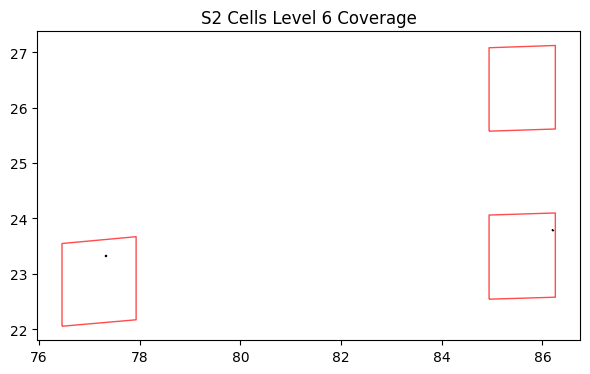

In [43]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [44]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [45]:
# note: this will have duplicate s2 cell rows with different state names if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,State Name
0,4173992429642317824,"POLYGON ((84.94013 25.57561, 86.25649 25.61509...",Bihar
1,4176244229456003072,"POLYGON ((84.94013 22.54055, 86.25649 22.57645...",Jharkhand
2,4142467232250724352,"POLYGON ((76.45631 22.05188, 77.92817 22.16857...",Madhya Pradesh


#### Download the S2 cells

In [46]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4173992429642317824 already exists.
File 4176244229456003072 already exists.
File 4142467232250724352 already exists.


## 6. Load rooftops and match to areas

TODO: I think this needs to be run again @poornimaramesh. I don't have all the VIDA rooftops downloaded so I can't do it easily. Once we run this we can directly use the `Ward Count IFS` column for sampling later.

In [47]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to filter and add area metadata to the rooftops
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [48]:
state_names = combined_gdf["State Name"].sort_values().unique()

for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_cell_id, gdf_subset
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Processing state: Bihar
Number of S2 cells that overlap our shapes in Bihar: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_49821/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


Processing state: Jharkhand
Number of S2 cells that overlap our shapes in Jharkhand: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_49821/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


Processing state: Madhya Pradesh
Number of S2 cells that overlap our shapes in Madhya Pradesh: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_49821/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


<Axes: >

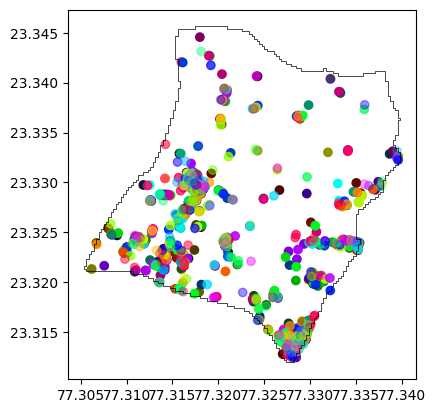

In [49]:
ax = matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)
gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [50]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in selected_states)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/3 [00:00<?, ?it/s]

In [51]:
len(matched_rooftops_gdf)

2066

In [52]:
matched_rooftops_gdf["State Name"].unique()

array(['Madhya Pradesh', 'Jharkhand'], dtype=object)

In [60]:
no_rooftop_PSU_IDs = set(combined_gdf["PSU_ID"].unique()).difference(set(matched_rooftops_gdf["PSU_ID"].unique()))
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU_ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PSU_ID
0,10.0,Bihar,215.0,Darbhanga,1184.0,Darbhanga,227041.0,0.0,Belhar,227041-0,...,Bihar,215.0,Darbhanga,1184.0,Darbhanga,Belhar,NaN,2378.0,"MULTIPOLYGON (((85.92485 26.18047, 85.92565 26...",TV_227041.0


In [61]:
no_rooftop_PSU_gdf.to_csv(
    OUTPUT_DATA_DIR / "Sampled PSUs" / "PSU_IDs_with_no_rooftops.csv",
    index=False,
)

## 8. Sample rooftops

### Filters

In [62]:
# filter to missing TV
matched_rooftops_gdf = matched_rooftops_gdf[matched_rooftops_gdf["TV Code"].isin(replacement_tv_codes)]

In [63]:
matched_rooftops_gdf["PSU_ID"].unique()

array(['TV_482460.0', 'TV_361598.0'], dtype=object)

### Do the sampling

### UPDATED: sampling runs on `Ward Count IFS` to begin with

In [64]:
ROOFTOPS_PER_WARD = 25

In [72]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 25

# Sample rooftops, multiplying by Ward Count for each PSU. 
sampled_rooftops = matched_rooftops_gdf.groupby(
    "PSU_ID", group_keys=False
).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD * int(x["Ward Count Panel"].iloc[0]), x.shape[0]),
        random_state=42
    )
)

In [75]:
# Check if Ward Count IFS is correctly influencing sample sizes
TEMP_ward_count_df = matched_rooftops_gdf[["PSU_ID", "Ward Count Panel"]].drop_duplicates()
TEMP_sampled_counts = (
    sampled_rooftops.groupby("PSU_ID").size() // ROOFTOPS_PER_WARD
).reset_index(name="Back-calculated Ward Count Panel")

# Merge the two dataframes
TEMP_check_df = TEMP_ward_count_df.merge(TEMP_sampled_counts, on="PSU_ID")
TEMP_check_df["Difference"] = TEMP_check_df["Ward Count Panel"] - TEMP_check_df["Back-calculated Ward Count Panel"]
TEMP_check_df

,PSU_ID,Ward Count Panel,Back-calculated Ward Count Panel,Difference
0,TV_482460.0,1,1,0
1,TV_361598.0,1,1,0


<Axes: >

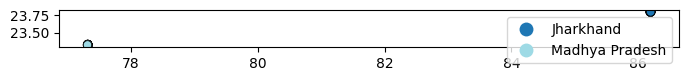

In [77]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="State Name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

In [79]:
# Red's code expects the column to be named "Ward Count" instead of "Ward Count Panel"
sampled_rooftops.rename(
    columns={"Ward Count Panel": "Ward Count"},
    inplace=True,
)

### Add sample-level rooftop numbering ID columns

In [80]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU_ID
sampled_rooftops["Rooftop PSU ID"] = sampled_rooftops.groupby("PSU_ID").cumcount() + 1
# add prefix of "PIN "  to the Rooftop PSU ID
sampled_rooftops["Rooftop PSU ID"] = "PIN " + sampled_rooftops["Rooftop PSU ID"].astype(str)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU_ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [81]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU_ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [84]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop Unique ID",

    ## Geospatial data
    "geometry",
    "latitude",
    "longitude",
    "gmap_link",

    ## PSU info
    "PSU_ID",
    "PSU Type",
    "Ward Count", # IFS only
    "Ward Count (All)",  # both IFS and Panel and Panel Round 2

    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",

    ## Admin information
    # "Sampled for Panel",
    # "Sampled for IFS",
    "Ward Boundary Available with MapSolve",
    # "Source Sheet",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",

    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    # "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",

    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [85]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [88]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU_ID" : "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_49821/1139571638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_rooftops_organised_gdf.rename(


In [89]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [90]:
sampled_rooftops_organised_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude,longitude,gmap_link,PSU ID,PSU Type,Ward Count,...,Delivery State,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve
1888,1,PIN 1,STATE_1_PSU_ID_TV_361598.0_ROOFTOP_PIN 1,POINT (86.19352 23.80102),23.801023,86.193523,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1414,2,PIN 2,STATE_2_PSU_ID_TV_361598.0_ROOFTOP_PIN 2,POINT (86.19039 23.79904),23.799038,86.190389,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1307,3,PIN 3,STATE_3_PSU_ID_TV_361598.0_ROOFTOP_PIN 3,POINT (86.18664 23.79826),23.798258,86.186635,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1408,4,PIN 4,STATE_4_PSU_ID_TV_361598.0_ROOFTOP_PIN 4,POINT (86.19008 23.79895),23.798945,86.190083,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1515,5,PIN 5,STATE_5_PSU_ID_TV_361598.0_ROOFTOP_PIN 5,POINT (86.19072 23.80001),23.800008,86.190724,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1576,6,PIN 6,STATE_6_PSU_ID_TV_361598.0_ROOFTOP_PIN 6,POINT (86.19309 23.80145),23.801454,86.193088,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
2052,7,PIN 7,STATE_7_PSU_ID_TV_361598.0_ROOFTOP_PIN 7,POINT (86.19953 23.79699),23.796986,86.199526,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1326,8,PIN 8,STATE_8_PSU_ID_TV_361598.0_ROOFTOP_PIN 8,POINT (86.18765 23.79779),23.797794,86.187649,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1782,9,PIN 9,STATE_9_PSU_ID_TV_361598.0_ROOFTOP_PIN 9,POINT (86.19750 23.79793),23.797934,86.197496,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0
1957,10,PIN 10,STATE_10_PSU_ID_TV_361598.0_ROOFTOP_PIN 10,POINT (86.19675 23.79983),23.799835,86.196746,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,GOOD - Town/Village boundary given as expected,20.0,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0


### Save sampled data (original rooftop pins)

In [91]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.801022509768647,86.19352277324249' of field sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'TV_361598.0' of field sampled_rooftops_centroids_original.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_centroids_original.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versio

## 9. Snap points to road

### Functions

In [92]:
from shapely import Point
import requests
from concurrent.futures import ThreadPoolExecutor


def get_nearest_point_on_road(point: Point, api_key: str) -> Point | None:
    """
    Retrieves the nearest point on the road for a given point using the Google Roads API.

    Args:
        point (Point): The point for which to find the nearest point on the road.
        api_key (str): Your Google Roads API key.

    Returns:
        Point: The nearest point on the road, or None if no point is found.

    """
    url = f"https://roads.googleapis.com/v1/snapToRoads?path={point.y},{point.x}&key={api_key}"
    response = requests.get(url)
    snapped_point = response.json().get("snappedPoints", [{}])[0].get("location")
    return (
        Point(snapped_point["longitude"], snapped_point["latitude"])
        if snapped_point
        else None
    )

def snap_point_to_road(args):
    """Helper function to snap a point to the nearest road."""
    idx, point, api_key = args
    try:
        snapped_point = get_nearest_point_on_road(point, api_key)
        return idx, snapped_point
    except Exception as e:
        print(f"Error snapping point at index {idx}: {str(e)}")
        return idx, None

def snap_points_to_roads_parallel(gdf, api_key, max_workers=10) -> gpd.GeoSeries:
    """
    Snap all points in a GeoDataFrame to the nearest road using parallel processing.
    
    Args:
        gdf: GeoDataFrame containing point geometries
        api_key: Google Roads API key
        max_workers: Number of parallel workers
        
    Returns:
        GeoSeries with snapped geometries
    """
    # Prepare arguments for parallel processing
    args_list = [(idx, point, api_key) for idx, point in enumerate(gdf.geometry)]
    
    # Initialize results dictionary
    snapped_points = {}
    
    # Process in parallel with progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks and track with tqdm
        results = list(tqdm(
            executor.map(snap_point_to_road, args_list), 
            total=len(args_list),
            desc="Snapping points to roads"
        ))
    
    # Process results
    for idx, snapped_point in results:
        snapped_points[idx] = snapped_point
    snapped_points_series = gpd.GeoSeries(snapped_points)

    return snapped_points_series

### Run

In [93]:
# load API key
import yaml
with open('../secrets/api_keys.yaml', 'r') as f:
    config = yaml.safe_load(f)
    api_key = config['GOOGLE_ROADS_API_KEY']

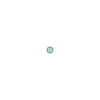

In [94]:
get_nearest_point_on_road(
    Point(77.11432151622034, 28.677391409999522), api_key
)

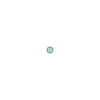

In [95]:
# test
get_nearest_point_on_road(
    sampled_rooftops_organised_gdf.geometry.iloc[0], api_key
)

In [96]:
len(sampled_rooftops_organised_gdf)

50

#### Snap points to road

In [97]:
snapped_points_series = snap_points_to_roads_parallel(
    sampled_rooftops_organised_gdf, 
    api_key,
    max_workers=12
)
# took 1min for 3,200 points

Snapping points to roads:   0%|          | 0/50 [00:00<?, ?it/s]

In [98]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = list(snapped_points_series)

In [99]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    50
Name: count, dtype: int64

In [100]:
sampled_rooftops_snapped_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude,longitude,gmap_link,PSU ID,PSU Type,Ward Count,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve,geometry_snapped,Geometry Type
1888,1,PIN 1,STATE_1_PSU_ID_TV_361598.0_ROOFTOP_PIN 1,POINT (86.19352 23.80102),23.801023,86.193523,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19354779999999 23.800848999999996),Snapped to Road
1414,2,PIN 2,STATE_2_PSU_ID_TV_361598.0_ROOFTOP_PIN 2,POINT (86.19039 23.79904),23.799038,86.190389,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19027353060676 23.799075422654173),Snapped to Road
1307,3,PIN 3,STATE_3_PSU_ID_TV_361598.0_ROOFTOP_PIN 3,POINT (86.18664 23.79826),23.798258,86.186635,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.1865785234735 23.798132109580422),Snapped to Road
1408,4,PIN 4,STATE_4_PSU_ID_TV_361598.0_ROOFTOP_PIN 4,POINT (86.19008 23.79895),23.798945,86.190083,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19020728297826 23.798904950521703),Snapped to Road
1515,5,PIN 5,STATE_5_PSU_ID_TV_361598.0_ROOFTOP_PIN 5,POINT (86.19072 23.80001),23.800008,86.190724,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19054550031828 23.80002320319486),Snapped to Road
1576,6,PIN 6,STATE_6_PSU_ID_TV_361598.0_ROOFTOP_PIN 6,POINT (86.19309 23.80145),23.801454,86.193088,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19308552665835 23.801578052363933),Snapped to Road
2052,7,PIN 7,STATE_7_PSU_ID_TV_361598.0_ROOFTOP_PIN 7,POINT (86.19953 23.79699),23.796986,86.199526,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19980833654685 23.796873924561805),Snapped to Road
1326,8,PIN 8,STATE_8_PSU_ID_TV_361598.0_ROOFTOP_PIN 8,POINT (86.18765 23.79779),23.797794,86.187649,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.18761604099551 23.79773123933061),Snapped to Road
1782,9,PIN 9,STATE_9_PSU_ID_TV_361598.0_ROOFTOP_PIN 9,POINT (86.19750 23.79793),23.797934,86.197496,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19754018597494 23.79806140001354),Snapped to Road
1957,10,PIN 10,STATE_10_PSU_ID_TV_361598.0_ROOFTOP_PIN 10,POINT (86.19675 23.79983),23.799835,86.196746,https://www.google.com/maps/search/?api=1&quer...,TV_361598.0,town_village,1,...,Jharkhand,354.0,Dhanbad,2582.0,Baghmara-Cum-Katras,NaN,361598,5170.0,POINT (86.19661523341844 23.79986593259737),Snapped to Road


#### Replace geometry to snapped one (missing filled in with original)

In [101]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [102]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [103]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.rename(
    columns={
        "latitude": "latitude_original",
        "longitude": "longitude_original",
        "gmap_link": "gmap_link_original",
    },
)

In [104]:
sampled_rooftops_snapped_gdf["latitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.y
)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [106]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop PSU ID",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "PSU ID",
        "PSU Type",
        "Ward Count", # IFS only
        "Ward Count (All)",  # IFS and Panel and Panel Round 2
        "State Code",
        "State Name",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "State Name_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        # "TV Code_MapSolve",
        "Ward Code_MapSolve",
        "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [107]:
from shapely.geometry import LineString

In [108]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [109]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [110]:
# Save snapped points
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.800848999999996,86.19354779999999' of field sampled_rooftops_snapped_points.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.801022509768647,86.19352277324249' of field sampled_rooftops_snapped_points.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'TV_361598.0' of field sampled_rooftops_snapped_points.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_points.State

In [111]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
    columns=["geometry_line", "geometry_original"]
),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.800848999999996,86.19354779999999' of field sampled_rooftops_snapped_lines.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.801022509768647,86.19352277324249' of field sampled_rooftops_snapped_lines.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'TV_361598.0' of field sampled_rooftops_snapped_lines.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_lines.State Cod

## Save per state

In [112]:
for state in sampled_rooftops_organised_gdf["State Name"].unique():
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state
    save_shapefiles(
        sampled_rooftops_organised_gdf[
            sampled_rooftops_organised_gdf["State Name"] == state
        ],
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet", "kml"],
    )

    # Save snapped points
    save_shapefiles(
        sampled_rooftops_snapped_gdf[
            sampled_rooftops_snapped_gdf["State Name"] == state
        ].drop(
            columns=[
                "geometry_original",
                "geometry_line",
            ]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet", "kml"],
    )

    # Save lines
    sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
    sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
    save_shapefiles(
        sampled_rooftops_line_gdf[
            sampled_rooftops_line_gdf["State Name"] == state
        ].drop(columns=["geometry_line", "geometry_original"]),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["csv", "parquet", "kml"],
    )

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=23.801022509768647,86.19352277324249' of field Jharkhand_sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'TV_361598.0' of field Jharkhand_sampled_rooftops_centroids_original.longitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field Jharkhand_sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field Jharkhand_sampled_rooftops_centroids_original.Ward Code parsed incompletely to real 0.
  o

## Side quests

### TEMP check Ward Count vs samples outputs

In [ ]:
# load the sampled rooftops data
sampled_rooftops_df = pd.read_csv(
    OUTPUT_DATA_DIR
    / "01. Sampled Rooftop Data"
    / "sampled_rooftops_snapped_points.csv"
)

In [ ]:
expected_samples_df = sample_df[sample_df["Sampled for IFS"] == "Yes"].groupby("State Name").size()*25
expected_samples_df.rename("Expected Samples", inplace=True)

In [ ]:
given_samples_series = sampled_rooftops_df.groupby("State Name").size()
given_samples_series.rename("Given Samples", inplace=True)
# merge the two series
n_samples_df = pd.concat([expected_samples_df, given_samples_series], axis=1)
n_samples_df

In [ ]:
n_samples_df["Difference"] = n_samples_df["Given Samples"] - n_samples_df["Expected Samples"]

In [ ]:
n_samples_df["Ward-Equivalent Difference"] = n_samples_df["Difference"] // 25

In [ ]:
n_samples_df

In [ ]:
n_samples_df[n_samples_df["Ward-Equivalent Difference"] > 0]

In [ ]:
n_samples_df["Difference"].hist(bins=50)

In [ ]:
n_samples_df.to_csv(
    OUTPUT_DATA_DIR / "n_samples_summary.csv",
    index=True,
)

### Side quest: Make subdistrict boundaries and share with Red

In [ ]:
# drop delhi wards because they've given us subdistricts for "NCT of Delhi" instead
gdf_without_delhi_wards = gdf[~(gdf["State Name"] == "Delhi")]
dissolved_subdistricts_gdf = gdf_without_delhi_wards.dissolve(
    by=["Subdistrict Code", "Subdistrict Name"], as_index=False
)

In [ ]:
dissolved_subdistricts_gdf["TV Code"] = np.nan
dissolved_subdistricts_gdf["TV Name"] = np.nan
dissolved_subdistricts_gdf["source"] = "dissolved subdistricts"

In [ ]:
# drop subdistricts with code 99999 as well and handle them separately
gdf_without_delhi_wards = gdf_without_delhi_wards[gdf_without_delhi_wards["Subdistrict Code"] != 99999]
gdf_99999 = gdf[gdf["Subdistrict Code"] == 99999]
tv_gdf_99999 = gdf_99999.dissolve(by=["TV Code", "TV Name"], as_index=False)

In [ ]:
sample_df[["Subdistrict Code", "Sampled for Panel", "Sampled for IFS"]]

ifs_subdistrict_codes = sample_df[
    (sample_df["Sampled for IFS"] == "Yes")
    & (sample_df["Subdistrict Code"].notna())
    & (sample_df["Subdistrict Code"] != 99999)  # Exclude the 99999 code
]["Subdistrict Code"].unique()

panel_subdistrict_codes = sample_df[
    (sample_df["Sampled for Panel"] == "Yes")
    & (sample_df["Subdistrict Code"].notna())
    & (sample_df["Subdistrict Code"] != 99999)  # Exclude the 99999 code
]["Subdistrict Code"].unique()

# tv codes
ifs_tv_codes_99999 = sample_df[
    (sample_df["Sampled for IFS"] == "Yes")
    & (sample_df["TV Code"].notna())
    & (sample_df["Subdistrict Code"] == 99999)  # Only include the 99999 code
]["TV Code"].unique()

panel_tv_codes_99999 = sample_df[
    (sample_df["Sampled for Panel"] == "Yes")
    & (sample_df["TV Code"].notna())
    & (sample_df["Subdistrict Code"] == 99999)  # Only include the 99999 code
]["TV Code"].unique()

In [ ]:
dissolved_subdistricts_gdf["Sampled for IFS"] = dissolved_subdistricts_gdf["Subdistrict Code"].isin(ifs_subdistrict_codes)
dissolved_subdistricts_gdf["Sampled for Panel"] = dissolved_subdistricts_gdf["Subdistrict Code"].isin(panel_subdistrict_codes)

In [ ]:
tv_gdf_99999["Sampled for IFS"] = tv_gdf_99999["TV Code"].isin(ifs_tv_codes_99999)
tv_gdf_99999["Sampled for Panel"] = tv_gdf_99999["TV Code"].isin(panel_tv_codes_99999)
tv_gdf_99999["source"] = "TVs with subdistrict 99999"

In [ ]:
concat_gdf = gpd.GeoDataFrame(
    pd.concat(
        [dissolved_subdistricts_gdf, tv_gdf_99999],
        ignore_index=True,
    )
)

In [ ]:
concat_gdf = concat_gdf[
    [
        "State Code",
        "State Name",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name",
        "source",
        "Sampled for IFS",
        "Sampled for Panel",
        "geometry",
    ]
]

In [ ]:
# save_shapefiles(
#     concat_gdf,
#     OUTPUT_DATA_DIR / "all_subdistricts",
#     "all_subdistricts",
#     formats=["csv", "shp", "parquet", "kml"],
# )

In [ ]:
# filter to only the subdistricts that were sampled for IFS
ifs_concat_gdf = concat_gdf[concat_gdf["Sampled for IFS"]]
# save_shapefiles(
#     ifs_concat_gdf,
#     OUTPUT_DATA_DIR / "ifs_subdistricts",
#     "ifs_subdistricts",
#     formats=["csv", "shp", "parquet", "kml"],
# )
# filter to only the subdistricts that were sampled for Panel
panel_concat_gdf = concat_gdf[concat_gdf["Sampled for Panel"]]
# save_shapefiles(
#     panel_concat_gdf,
#     OUTPUT_DATA_DIR / "panel_subdistricts",
#     "panel_subdistricts",
#     formats=["csv", "shp", "parquet", "kml"],
# )

## Scraps

In [ ]:
# def create_grid_points(gdf, cell_size=0.05) -> gpd.GeoDataFrame:
#     """
#     Create a grid of points within the bounds of the unary geometry of the GeoDataFrame.

#     Parameters:
#     - gdf: GeoDataFrame
#     - cell_size: float, size of the grid cells

#     Returns:
#     - GeoDataFrame with grid points
#     """

#     bounds = gdf.unary_union.bounds
#     min_lon, min_lat, max_lon, max_lat = bounds

#     # Create a grid of points
#     lons = np.arange(min_lon, max_lon, cell_size)
#     lats = np.arange(min_lat, max_lat, cell_size)
#     lon_grid, lat_grid = np.meshgrid(lons, lats)

#     # Flatten the grid and create a GeoDataFrame
#     points = gpd.GeoDataFrame(
#         geometry=gpd.points_from_xy(lon_grid.flatten(), lat_grid.flatten()),
#         crs="EPSG:4326",
#     )

#     # Filter points that are within the unary geometry
#     points = points[points.geometry.within(gdf.unary_union)]

#     return points

In [ ]:
# import os
# import concurrent.futures
# from concurrent.futures import ThreadPoolExecutor

# def download_VIDA_rooftops_data_by_s2(
#     s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path, n_jobs: int = -1
# ) -> None:
#     """
#     Download S2 rooftops data for multiple S2 cell IDs in parallel.

#     Args:
#         s2_cell_ids: List of S2 cell IDs to download data for
#         country_iso_code: ISO code for the country (e.g. "IND", "PHL")
#         target_data_dir: Directory to save downloaded files
#         n_jobs: Number of concurrent downloads. If -1, uses all available cores.
#     """

#     if not isinstance(n_jobs, int) or n_jobs < -1 or n_jobs == 0:
#         raise ValueError("n_jobs must be -1 or a positive integer.")

#     if n_jobs == -1:
#         n_jobs = os.cpu_count() or 1  # 1 in case os.cpu_count() returns None

#     print(f"Downloading rooftops data for {len(s2_cell_ids)} S2 cell IDs in parallel using {n_jobs} jobs.")

#     # Track errors
#     error_count = 0
#     errors = {}

#     # Define a wrapper function to handle exceptions
#     def download_with_error_handling(s2_cell_id, country_iso_code, target_data_dir):
#         try:
#             download_VIDA_rooftops_data_by_s2_single(s2_cell_id, country_iso_code, target_data_dir)
#             return s2_cell_id, None
#         except Exception as e:
#             return s2_cell_id, str(e)

#     # Use ThreadPoolExecutor for I/O bound operations
#     with ThreadPoolExecutor(max_workers=n_jobs) as executor:
#         futures = [
#             executor.submit(
#                 download_with_error_handling, s2_cell_id, country_iso_code, target_data_dir
#             )
#             for s2_cell_id in s2_cell_ids
#         ]

#         # Show progress with tqdm
#         progress_bar = tqdm(
#             total=len(futures),
#             desc="Downloading rooftops data"
#         )

#         for future in concurrent.futures.as_completed(futures):
#             s2_cell_id, error = future.result()

#             if error:
#                 error_count += 1
#                 errors[s2_cell_id] = error
#                 progress_bar.set_description(f"Downloading rooftops data (errors: {error_count})")

#             progress_bar.update(1)

#         progress_bar.close()

#     # Print summary of errors
#     if errors:
#         print(f"\n⚠️ {error_count} errors occurred during download:")
#         for s2_cell_id, error in errors.items():
#             print(f"  - S2 cell {s2_cell_id}: {error}")
#         print(f"{len(s2_cell_ids) - error_count} of {len(s2_cell_ids)} files downloaded successfully.")
#     else:
#         print(f"\n✅ All {len(s2_cell_ids)} files downloaded successfully.")